In [1]:
import sys
sys.path.append("../src")

In [2]:
from data_loader import data_stock_loader
from statsmodels.tsa.stattools import adfuller

In [3]:
from preprocessing import train_test_split_series
from utils import calculate_rmse

In [4]:
df = data_stock_loader()
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1254 entries, 2021-08-05 to 2026-08-04
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          1254 non-null   float64
 1   High          1254 non-null   float64
 2   Low           1254 non-null   float64
 3   Close         1254 non-null   float64
 4   Volume        1254 non-null   int64  
 5   Dividends     1254 non-null   float64
 6   Stock Splits  1254 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 78.4 KB


In [5]:
result = adfuller(df["Close"].dropna())
print("ADF Statistic: %f" % result[0])
print("p-value: %f" % result[1])
print("Critical Values:")
for key, value in result[4].items():
    print("\t%s: %.3f" % (key, value))

ADF Statistic: -1.033698
p-value: 0.740776
Critical Values:
	1%: -3.436
	5%: -2.864
	10%: -2.568


In [6]:
df["Close_diff"] = df["Close"].diff()
result_diff = adfuller(df["Close_diff"].dropna())
print("ADF Statistic: %f" % result_diff[0])
print("p-value: %f" % result_diff[1])
print("Critical Values:")
for key, value in result_diff[4].items():
    print("\t%s: %.3f" % (key, value))

ADF Statistic: -34.366631
p-value: 0.000000
Critical Values:
	1%: -3.436
	5%: -2.864
	10%: -2.568


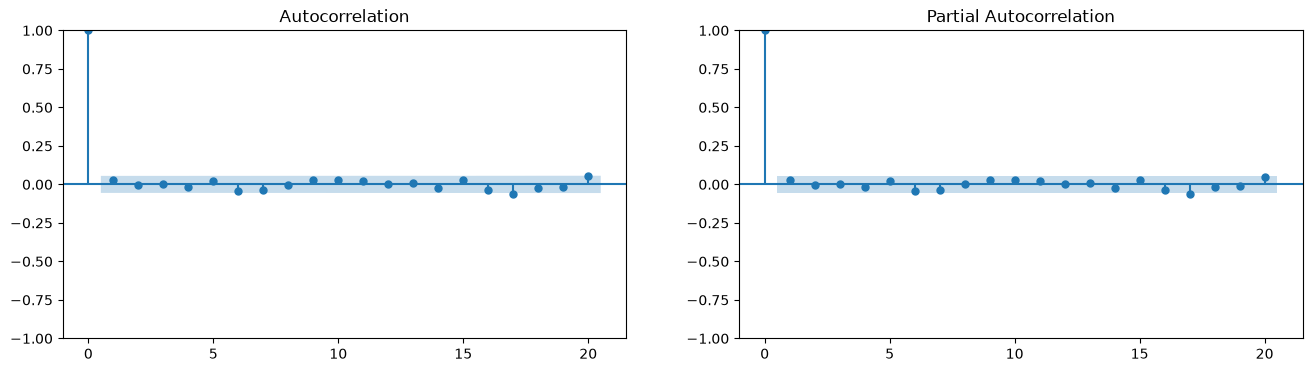

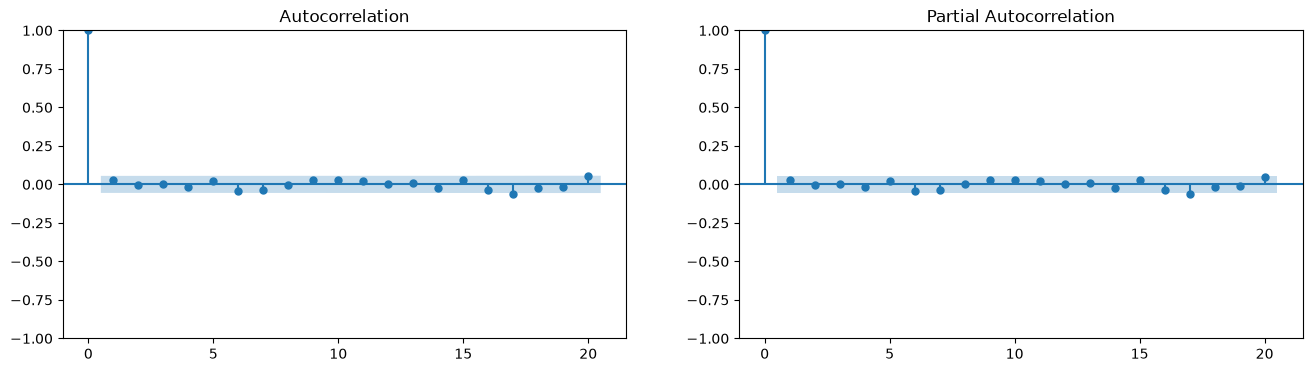

In [7]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(df["Close_diff"].dropna(), lags=20, ax=axes[0])
plot_pacf(df["Close_diff"].dropna(), lags=20, ax=axes[1])

In [8]:
from statsmodels.tsa.arima.model import ARIMA
train, test = train_test_split_series(df['Close'])

train = train.asfreq("B")
test = test.asfreq("B").ffill()

len(train), len(test)

(1173, 131)

In [9]:
model = ARIMA(train, order=(0, 1, 0))
model_fit= model.fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 1173
Model:                 ARIMA(0, 1, 0)   Log Likelihood               -3559.867
Date:                Wed, 26 Aug 2026   AIC                           7121.734
Time:                        14:19:18   BIC                           7126.800
Sample:                    08-05-2021   HQIC                          7123.644
                         - 02-02-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2        31.5592      0.614     51.431      0.000      30.357      32.762
Ljung-Box (L1) (Q):                   0.07   Jarque-Bera (JB):              3057.94
Prob(Q):                              0.79   Pr

In [10]:
forecast = model_fit.forecast(steps=len(test))

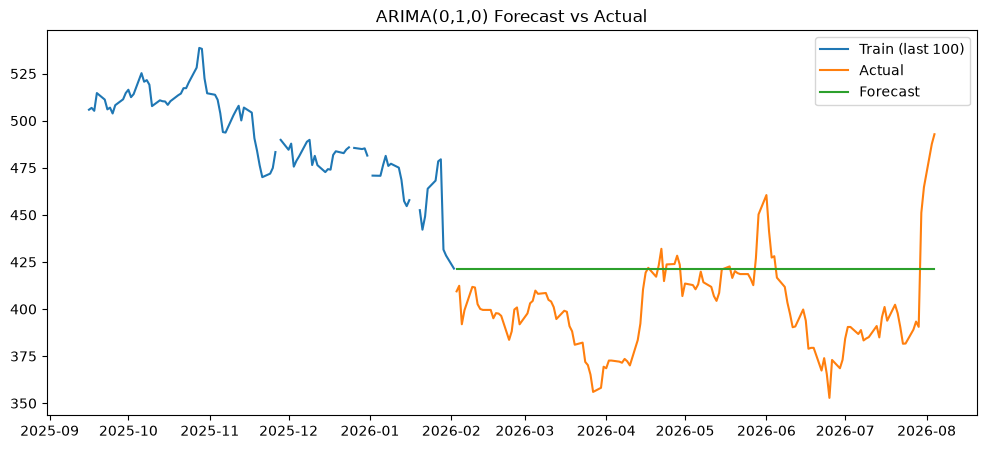

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(train.index[-100:], train[-100:], label="Train (last 100)")
plt.plot(test.index, test, label="Actual")
plt.plot(test.index, forecast, label="Forecast")
plt.legend()
plt.title("ARIMA(0,1,0) Forecast vs Actual")
plt.show()

In [12]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = calculate_rmse(test, forecast)
print(rmse)

31.530821250005292


In [13]:
results = {"ARIMA(0,1,0)": rmse}

for order in [(1,1,1), (2,1,2)]:
    model = ARIMA(train, order=order)
    fit = model.fit()
    fc = fit.forecast(steps=len(test))
    r = np.sqrt(mean_squared_error(test, fc))
    results[f"ARIMA{order}"] = r
    print(f"ARIMA{order} -> RMSE: {r:.4f}, AIC: {fit.aic:.2f}")

print(results)

ARIMA(1, 1, 1) -> RMSE: 34.1644, AIC: 7122.43


d:\ML projects\Stock price\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
d:\ML projects\Stock price\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


ARIMA(2, 1, 2) -> RMSE: 31.4234, AIC: 7120.73
{'ARIMA(0,1,0)': np.float64(31.530821250005292), 'ARIMA(1, 1, 1)': np.float64(34.16438380689604), 'ARIMA(2, 1, 2)': np.float64(31.423387441006582)}


In [14]:
import joblib

best_model = ARIMA(train, order=(2,1,2)).fit()
joblib.dump(best_model, "../models/arima_model.pkl")

['../models/arima_model.pkl']

In [15]:
import json

with open("../models/arima_model_results.json", "w") as f:
    json.dump(results, f, indent=2)